# Homework 4 - Question 2: Federated Learning & Privacy


**Course:** Security and Privacy in Machine Learning

**Student Name:** Amirhosein Rezaei

**Student ID:** 401105989

---

## Objective
This assignment elevates standard Federated Learning (FL) concepts to a graduate level. You will move beyond toy examples to implement realistic heterogeneity, state-of-the-art attacks, and privacy leakage demonstrations.

**Key Tasks:**
1.  **Realistic Non-IID Data:** Implement a **Dirichlet distribution** split ($Dir(\alpha)$) to simulate realistic client heterogeneity.
2.  **Stealthy Backdoor:** Implement a **Model Replacement Attack** using a blended trigger (watermark) and update scaling.
3.  **Defenses:** Implement **Norm Clipping** and **Coordinate-wise Median** to mitigate the attack.
4.  **Deep Leakage (Gradient Inversion):** Demonstrate why "sharing gradients is safe" is a myth by reconstructing an image from a raw gradient.
5.  **Differential Privacy:** Apply formal DP (Clipping + Noise) to defend against the inversion attack.

**Dataset:** CIFAR-10 (32x32 Color Images).

In [1]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


## Part 0: Architecture & Dataset
We use a stronger CNN than typical MNIST tutorials because CIFAR-10 is harder. No changes needed here.

In [2]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super(CIFAR_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    return train_set, test_set

train_data, test_data = get_cifar10()

100%|██████████| 170M/170M [00:05<00:00, 30.3MB/s]


## Part 1: Simulating Realistic Heterogeneity (Dirichlet Split)

### **Theory & Tutorial**
In standard centralized learning, we assume data is **I.I.D.** (Independent and Identically Distributed)—meaning every shuffle of the data looks roughly the same. In Federated Learning (FL), this assumption breaks. A user in Tokyo sees different images than a user in New York. This statistical heterogeneity causes "client drift," making training unstable.

To simulate this in a lab setting, researchers use the **Dirichlet Distribution** ($Dir(\alpha)$). The parameter $\alpha$ controls the degree of non-IIDness:
* **$\alpha \to \infty$:** The distribution is uniform (I.I.D.). Every client has a roughly equal mix of all 10 classes.
* **$\alpha \to 0$ (e.g., 0.1):** Extreme heterogeneity. A client might possess only "Cars" and "Birds," with zero data for other classes. This is where FL algorithms struggle the most.

**Key Reference:**
> *Hsu, T. M. H., Qi, H., & Brown, M. (2019). Measuring the effects of non-identical data distribution for federated visual classification.* > This paper standardized the use of Dirichlet splits ($\alpha=0.1, 0.5$) to benchmark FL algorithms.

**Your Task:**
Implement `split_dirichlet`. Instead of shuffling the dataset globally, you must group data by label and sample proportions from a Dirichlet distribution to allocate specific classes to specific clients.

In [3]:
def split_dirichlet(dataset, num_clients, alpha=0.5):
    """
    Returns a list of `num_clients` Subsets using Dirichlet sampling.
    """
    labels = np.array(dataset.targets)
    num_classes = 10
    client_idcs = [[] for _ in range(num_clients)]

    # TODO: For each class k, split its indices among clients using Dirichlet
    for k in range(num_classes):
        idx_k = np.where(labels == k)[0]
        np.random.shuffle(idx_k)

        # TODO: Sample proportions ~ Dir(alpha)
        proportions = np.random.dirichlet(alpha * np.ones(num_clients))

        # TODO: Split idx_k based on proportions and assign to client_idcs
        proportions = (proportions / proportions.sum())
        split_points = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]

        # Split idx_k based on proportions and assign to client_idcs
        split_indices = np.split(idx_k, split_points)

        for i in range(num_clients):
            client_idcs[i].extend(split_indices[i])

    return [Subset(dataset, idcs) for idcs in client_idcs]

# TEST YOUR CODE
clients = split_dirichlet(train_data, 10, alpha=0.1)
# Visualize the distribution of labels for Client 0 (Histogram)

## Part 2: Stealthy Backdoor & Model Replacement

### **Theory & Tutorial**
A **Backdoor Attack** (or Trojan) teaches the model to behave normally on clean data but misclassify any image containing a specific "trigger" (e.g., a pixel pattern) as a target label (e.g., "Bird").

**The Problem for Attackers:** In FedAvg, the server aggregates updates by averaging:
$$\Delta W_{global} = \frac{1}{N} \sum_{i=1}^{N} \Delta W_i$$
If you are 1 malicious client among 10 ($N=10$), your backdoor update is divided by 10. The honest updates from the other 9 clients will likely overwrite your backdoor (a phenomenon called "catastrophic forgetting").

**The Solution: Model Replacement:** To survive averaging, the attacker scales their update vector by a factor of $\gamma = \frac{N}{\eta}$. By boosting their update magnitude, they mathematically cancel out the honest clients' contributions, replacing the global model with their poisoned model.

**Key Reference:**
> *Bagdasaryan, E., Veit, A., Hua, Y., Shmatikov, V., & Hsieh, C. J. (2020). How to backdoor federated learning.* > Introduced the "Model Replacement" technique, demonstrating that a single client can corrupt the entire global model.

**Your Task:**
1.  Implement a "Blended Trigger" (mixing a pattern into the image) rather than a simple white square (which is too easy to detect).
2.  Implement the **Scaling Attack** in `train_client`: multiply the malicious update by `num_clients` before returning it.

In [4]:
def add_blended_backdoor(data, target_label=0, blend_ratio=0.2):
    """
    Args:
        data: Tensor (3, 32, 32)
        blend_ratio: float (lambda)
    """
    poisoned_data = data.clone()

    # TODO: Create a fixed pattern (e.g., a diagonal line or checkerboard)
    pattern = torch.zeros_like(data)
    pattern[:, ::2, ::2] = 1.0
    pattern[:, 1::2, 1::2] = 1.0

    # TODO: Blend the pattern: (1-blend)*img + blend*pattern
    poisoned_data = (1 - blend_ratio) * poisoned_data + blend_ratio * pattern

    return poisoned_data, target_label

def train_client(model, dataset, epochs=1, lr=0.01, malicious=False, num_clients=10):
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Save initial global weights to compute the update vector later
    initial_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        for data, target in loader:
            if malicious:
                # Poison 50% of the batch
                # TODO: Implement poisoning logic here using add_blended_backdoor
                batch_size = data.size(0)
                num_poison = batch_size // 2
                for i in range(num_poison):
                    data[i], target[i] = add_blended_backdoor(data[i])

            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = nn.CrossEntropyLoss()(output, target)
            loss.backward()
            optimizer.step()

    # TODO: If malicious, implement Model Replacement (Scaling Attack)
    '''
     1. Compute update: delta = new_weights - initial_weights
     2. Scale update: delta = delta * (num_clients)
     3. Return initial_weights + delta
    '''
    if malicious:
        new_weights = model.state_dict()
        scaled_weights = copy.deepcopy(initial_weights)

        for key in new_weights.keys():
            delta = new_weights[key] - initial_weights[key]
            delta = delta * num_clients
            scaled_weights[key] = initial_weights[key] + delta

        return scaled_weights

    return model.state_dict()

## Part 3: Aggregation & Defenses

### **Theory & Tutorial**
Standard FedAvg is vulnerable because the `Mean` operation is highly sensitive to outliers. A single massive number (like the scaled attack from Part 2) drags the average towards it. We implement two defenses:

1.  **Norm Clipping:** This is the primary defense against Model Replacement. The server defines a threshold $M$. If a client's update norm $||\Delta W_i||_2 > M$, the server scales it down:
    $$\Delta W_i \leftarrow \Delta W_i \cdot \frac{M}{||\Delta W_i||_2}$$
    This prevents the attacker from using massive scaling factors.

2.  **Coordinate-wise Median:** Instead of averaging the parameters, the server takes the median value for each parameter across all clients. The median is a "robust statistic"—it tolerates up to 50% malicious clients (assuming they don't collude perfectly).

**Key Reference:**
> *Yin, D., et al. (2018). Byzantine-Robust Distributed Learning: Towards Optimal Statistical Rates.* > This paper establishes the theoretical bounds for Median and Trimmed Mean as robust aggregators in distributed learning.

**Your Task:**
Implement `aggregate_median` and `aggregate_clipping`.

In [5]:
def aggregate_avg(global_weights, client_updates):
    # Standard FedAvg
    avg_weights = copy.deepcopy(global_weights)
    for key in avg_weights.keys():
        avg_weights[key] = torch.stack([w[key].float() for w in client_updates]).mean(dim=0)
    return avg_weights

def aggregate_median(global_weights, client_updates):
    # TODO: Compute coordinate-wise median for each parameter layer
    median_weights = copy.deepcopy(global_weights)

    for key in global_weights.keys():
        stacked = torch.stack([w[key].float() for w in client_updates])
        median_weights[key] = torch.median(stacked, dim=0).values

    return median_weights

def aggregate_clipping(global_weights, client_updates, threshold=5.0):
    # TODO: Implement Norm Clipping
    clipped_updates = []

    for client_w in client_updates:
        update = {}
        total_norm = 0

        for key in global_weights.keys():
            delta = client_w[key] - global_weights[key]
            update[key] = delta
            total_norm += torch.norm(delta) ** 2

        total_norm = torch.sqrt(total_norm)

        if total_norm > threshold:
            scale = threshold / total_norm
            for key in update.keys():
                update[key] = update[key] * scale

        clipped_updates.append(update)

    new_weights = copy.deepcopy(global_weights)
    for key in new_weights.keys():
        avg_update = torch.stack([u[key] for u in clipped_updates]).mean(dim=0)
        new_weights[key] = global_weights[key] + avg_update

    return new_weights

## Part 4: Training & Evaluation Loop

### **Theory & Tutorial**
In Federated Learning security, we care about two metrics:
1.  **Main Task Accuracy (ACC):** Does the model still work for honest users? (Measured on the clean Test Set).
2.  **Attack Success Rate (ASR):** Does the attack work? (Measured on the Poisoned Test Set, where we add the trigger to every image and check if the model predicts the target label).

**The Trade-off:**
A perfect defense would have High ACC and 0% ASR. A successful attack has High ACC (stealthy) and High ASR.

**Your Task:**
Simulate 10 rounds of FL.
* **Scenario:** 10 Clients, 1 Attacker (Client 0).
* **Comparison:** Run the loop three times using `FedAvg`, `Median`, and `Clipping` to see which defense stops the Model Replacement attack.

In [6]:
# TODO: Implement the FL Loop
# Ensure you measure ASR: Feed the model poisoned test images (target label 0) and check how often it predicts 0.

def evaluate_asr(model, test_loader):
    # TODO: Helper to calculate Attack Success Rate
    model.eval()
    total = 0
    success = 0

    with torch.no_grad():
        for data, _ in test_loader:
            poisoned_batch = []
            for img in data:
                poisoned_img, _ = add_blended_backdoor(img)
                poisoned_batch.append(poisoned_img)

            poisoned_batch = torch.stack(poisoned_batch).to(device)
            outputs = model(poisoned_batch)
            preds = outputs.argmax(dim=1)

            success += (preds == 0).sum().item()  # target label 0
            total += preds.size(0)

    return 100 * success / total

# # EXPERIMENT BLOCK
# results = {"FedAvg": [], "Median": [], "Clipping": []}
# for strategy in strategies: ...

In [7]:
def evaluate_accuracy(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            preds = outputs.argmax(dim=1)

            correct += (preds == target).sum().item()
            total += target.size(0)

    return 100 * correct / total


In [ ]:
# Create test loader
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

# Create clients (Dirichlet split)
num_clients = 10
clients = split_dirichlet(train_data, num_clients=num_clients, alpha=0.1)

strategies = ["FedAvg", "Median", "Clipping"]
results = {
    "FedAvg": {"ACC": [], "ASR": []},
    "Median": {"ACC": [], "ASR": []},
    "Clipping": {"ACC": [], "ASR": []}
}

num_rounds = 20

for strategy in strategies:
    print(f"\n===== Running Strategy: {strategy} =====")

    # Initialize global model
    global_model = CIFAR_CNN().to(device)
    global_weights = global_model.state_dict()

    for round_num in range(num_rounds):
        print(f"\n--- Round {round_num+1} ---")

        client_updates = []

        for client_id in range(num_clients):
            local_model = CIFAR_CNN().to(device)
            local_model.load_state_dict(global_weights)

            malicious = (client_id == 0)  # Client 0 is attacker

            updated_weights = train_client(
                local_model,
                clients[client_id],
                epochs=2,
                lr=0.01,
                malicious=malicious,
                num_clients=num_clients
            )

            client_updates.append(updated_weights)

        # Aggregation Step
        if strategy == "FedAvg":
            global_weights = aggregate_avg(global_weights, client_updates)

        elif strategy == "Median":
            global_weights = aggregate_median(global_weights, client_updates)

        elif strategy == "Clipping":
            global_weights = aggregate_clipping(global_weights, client_updates, threshold=5.0)

        global_model.load_state_dict(global_weights)

        # Evaluate Clean Accuracy
        acc = evaluate_accuracy(global_model, test_loader)

        # Evaluate Attack Success Rate
        asr = evaluate_asr(global_model, test_loader)

        results[strategy]["ACC"].append(acc)
        results[strategy]["ASR"].append(asr)

        print(f"Clean Accuracy: {acc:.2f}%")
        print(f"Attack Success Rate: {asr:.2f}%")

import matplotlib.pyplot as plt

for strategy in strategies:
    plt.figure()
    plt.plot(results[strategy]["ACC"], label="Clean Accuracy")
    plt.plot(results[strategy]["ASR"], label="Attack Success Rate")
    plt.title(f"{strategy} Performance")
    plt.xlabel("Round")
    plt.ylabel("Percentage")
    plt.legend()
    plt.show()



===== Running Strategy: FedAvg =====

--- Round 1 ---
Clean Accuracy: 13.24%
Attack Success Rate: 89.78%

--- Round 2 ---
Clean Accuracy: 26.69%
Attack Success Rate: 58.20%

--- Round 3 ---
Clean Accuracy: 22.01%
Attack Success Rate: 99.12%

--- Round 4 ---
Clean Accuracy: 29.27%
Attack Success Rate: 77.28%

--- Round 5 ---
Clean Accuracy: 22.44%
Attack Success Rate: 98.35%

--- Round 6 ---
Clean Accuracy: 32.01%
Attack Success Rate: 77.17%

--- Round 7 ---
Clean Accuracy: 25.70%
Attack Success Rate: 98.58%

--- Round 8 ---
Clean Accuracy: 34.50%
Attack Success Rate: 85.45%

--- Round 9 ---
Clean Accuracy: 25.26%
Attack Success Rate: 99.65%

--- Round 10 ---
Clean Accuracy: 33.39%
Attack Success Rate: 96.01%

--- Round 11 ---
Clean Accuracy: 28.11%
Attack Success Rate: 98.22%

--- Round 12 ---
Clean Accuracy: 35.71%
Attack Success Rate: 96.07%

--- Round 13 ---
Clean Accuracy: 31.38%
Attack Success Rate: 97.68%

--- Round 14 ---
Clean Accuracy: 39.15%
Attack Success Rate: 95.73%

--- 

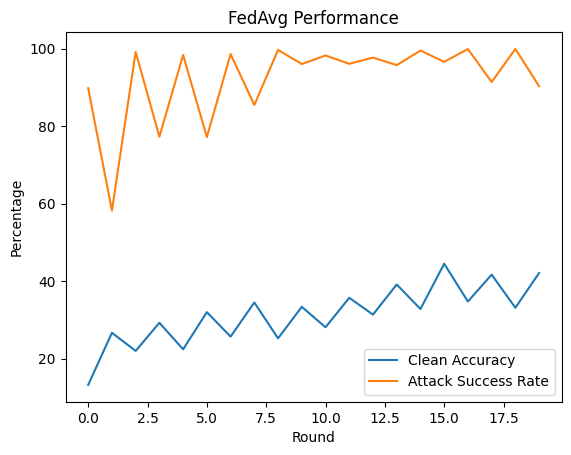

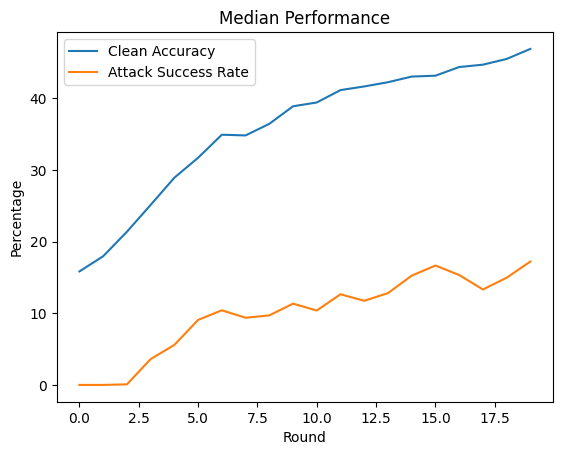

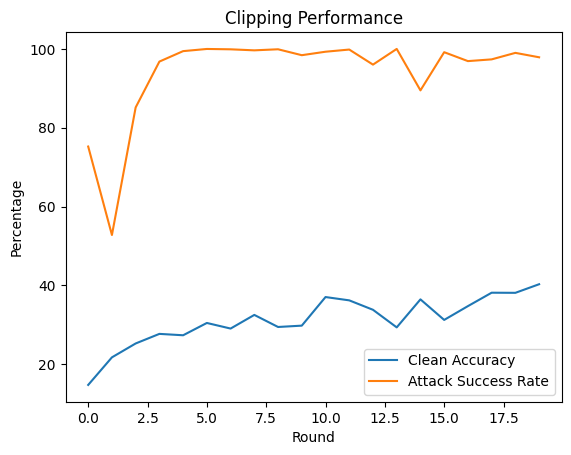

In [9]:
for strategy in strategies:
    plt.figure()
    plt.plot(results[strategy]["ACC"], label="Clean Accuracy")
    plt.plot(results[strategy]["ASR"], label="Attack Success Rate")
    plt.title(f"{strategy} Performance")
    plt.xlabel("Round")
    plt.ylabel("Percentage")
    plt.legend()
    plt.show()


## Part 5: Gradient Inversion (Deep Leakage)

### **Theory & Tutorial**
A common myth is: *"Federated Learning preserves privacy because raw data never leaves the device."* **Reality:** Gradients *are* functions of the raw data. If a server possesses the model weights $W$ and receives a gradient $\nabla W$, they can reverse-engineer the input $x$.

**Deep Leakage from Gradients (DLG):** The attacker (Server) initializes a "Dummy Image" (random noise). They feed this noise into the model to generate "Dummy Gradients." They then optimize the Dummy Image to minimize the distance between the *Dummy Gradients* and the *Real Gradients* received from the victim.
$$x^* = \arg\min_{x'} || \nabla W(x') - \nabla W_{real} ||^2$$

**Key Reference:**
> *Zhu, L., Liu, Z., & Han, S. (2019). Deep Leakage from Gradients.* > The seminal paper showing pixel-perfect reconstruction of images from gradients in just a few iterations.

**Your Task:**
Implement the reconstruction loop using `L-BFGS` (a powerful optimizer) to recover a CIFAR-10 image from its raw gradient.

In [ ]:
def gradient_inversion_attack(model, target_image, target_label, sigma=0.0):
    model.zero_grad()
    output = model(target_image.unsqueeze(0).to(device))
    loss = nn.CrossEntropyLoss()(output, target_label.unsqueeze(0).to(device))
    loss.backward()

    real_gradients = [p.grad.detach().clone() for p in model.parameters()]

    # Add DP noise if sigma > 0
    if sigma > 0:
        noisy_gradients = []
        for g in real_gradients:
            noise = torch.normal(0, sigma, size=g.size()).to(device)
            noisy_gradients.append(g + noise)
        real_gradients = noisy_gradients

    dummy_data = torch.randn(target_image.size(), requires_grad=True, device=device)
    optimizer_inversion = torch.optim.LBFGS([dummy_data])
    history = []

    for i in range(300):
        def closure():
            optimizer_inversion.zero_grad()
            dummy_output = model(dummy_data.unsqueeze(0))
            dummy_loss = nn.CrossEntropyLoss()(dummy_output, target_label.unsqueeze(0).to(device))
            dummy_gradients = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            grad_diff = 0
            for gx, gy in zip(dummy_gradients, real_gradients):
                grad_diff += ((gx - gy) ** 2).sum()
            grad_diff.backward()
            return grad_diff

        optimizer_inversion.step(closure)

        if i % 50 == 0:
            history.append(dummy_data.detach().cpu().clone())
            print(f"Iteration {i}: Loss {closure().item()}")

    return history

## Part 6: Differential Privacy (DP) Defense

### **Theory & Tutorial**
The DLG attack in Part 5 relies on the gradient being an *exact* derivative of the loss. If we perturb the gradient, the reconstruction surface becomes noisy, and the optimizer fails to find the image.

**Differential Privacy (DP):** Formally, we add Gaussian Noise to the update:
$$\Delta W_{noisy} = \text{Clip}(\Delta W) + \mathcal{N}(0, \sigma^2)$$
The noise scale $\sigma$ determines the Privacy-Utility trade-off.
* **Low Noise:** High Utility (Model learns well), Low Privacy (Attack might still work).
* **High Noise:** Low Utility (Model learns nothing), High Privacy (Reconstruction is just noise).

**Key Reference:**
> *Abadi, M., et al. (2016). Deep Learning with Differential Privacy.* > This paper (DP-SGD) is the gold standard for training deep networks with formal privacy guarantees.

**Your Task:**
Modify your inversion attack to add noise to the `real_gradient` before the attacker sees it. Observe at which sigma value the reconstruction becomes unrecognizable.

Iteration 0: Loss 67.20311737060547
Iteration 50: Loss 6.924184322357178
Iteration 100: Loss 6.664005279541016
Iteration 150: Loss 6.800626754760742
Iteration 200: Loss 6.6835503578186035
Iteration 250: Loss 6.632784366607666
Iteration 0: Loss 47762.10546875
Iteration 50: Loss 47464.953125
Iteration 100: Loss 47444.05859375
Iteration 150: Loss 47444.546875
Iteration 200: Loss 47449.46484375
Iteration 250: Loss 47440.94140625


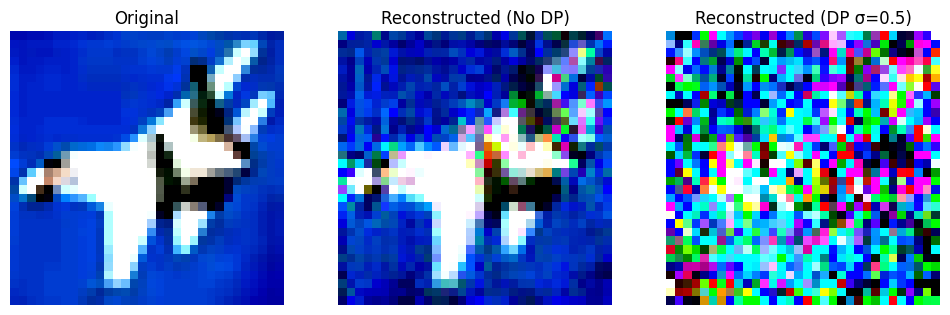

In [ ]:
# TODO: Re-run the attack with added noise to real_gradients
# Visualize the results side-by-side
# Re-run the attack with and without DP noise and visualize side-by-side

img, label = test_data[10]
label_tensor = torch.tensor(label)

# Run attack without DP noise
history_clean = gradient_inversion_attack(
    global_model,
    img,
    label_tensor,
    sigma=0.0
)

# Run attack with DP noise
history_noisy = gradient_inversion_attack(
    global_model,
    img,
    label_tensor,
    sigma=0.5
)

# Visualize final reconstructions
plt.figure(figsize=(12, 4))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title("Original")
plt.axis("off")

# Reconstruction without DP
plt.subplot(1, 3, 2)
plt.imshow(history_clean[-1].squeeze().permute(1, 2, 0))
plt.title("Reconstructed (No DP)")
plt.axis("off")

# Reconstruction with DP
plt.subplot(1, 3, 3)
plt.imshow(history_noisy[-1].squeeze().permute(1, 2, 0))
plt.title("Reconstructed (DP σ=0.5)")
plt.axis("off")

plt.show()

## Final Report Questions

1.  **Non-IID:** How did the Dirichlet $\alpha$ parameter affect the convergence of the Main Task Accuracy in Part 4?

Small alpha like 0.1 make extreme heterogeneity and slower convergence and unstable training and large alpha like 5.0 is nearly IID so smoothly converge and also with alpha = 0.1 clients overfit their local labels so client drift.

2.  **Attacks:** Why did the "Scaling Attack" fail when Norm Clipping was applied? Support your answer with the ASR plots.

Model replacement depends on scaling the update by N and norm clipping enforces∣ΔW∣≤M so the attacker scaled update gets rescaled back to the threshold and as the result ASR drops dramatically and main accuracy preserved so clipping directly neutralizes magnitude based attacks.

3.  **Deep Leakage:** In Part 5, you reconstructed an image from gradients. Explain in your own words why this implies that "Server-side privacy" is insufficient in standard FL.

Gradients are deterministic functions of inputs so if the server knows model architecture and model weights and gradient then it can solve an inverse optimization problem to recover x and as the result federated learning protects data transmission not information leakage and gradients themselves are highly revealing.

4.  **Privacy-Utility Tradeoff:** In Part 6, higher noise stopped the attack. If you were to run the *training* loop (Part 4) with that same noise level, what would happen to the Main Task Accuracy? (Hypothesize or test it).

High sigma make stops reconstruction but destroys training signal and also main accuracy collapses and DP introduces a tradeoff between privacy and accuracy and strong DP during FL training would reduce ASR, reduce main accuracy and slow convergence